In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

departments = ["Retail Banking", "Corporate Banking", "HR", "IT", "Risk", "Finance"]
branches = ["Delhi", "Mumbai", "Chennai", "Kolkata", "Bangalore"]

data = pd.DataFrame({
    "Employee_ID": range(1, n+1),
    "Department": np.random.choice(departments, n),
    "Branch": np.random.choice(branches, n),
    "Experience": np.random.randint(0, 20, n),
    "Performance_Score": np.round(np.random.uniform(1, 5, n), 1),
    "Salary": np.random.randint(30000, 150000, n),
    "Monthly_Sales": np.random.randint(50000, 500000, n),
    "Training_Hours": np.random.randint(5, 100, n)
})

# Attrition Risk Logic
data["Attrition_Risk"] = np.where(
    (data["Performance_Score"] < 2.5) & (data["Experience"] < 3),
    "High",
    np.where(data["Performance_Score"] < 3, "Medium", "Low")
)

# Promotion Eligibility
data["Promotion_Eligible"] = np.where(
    (data["Performance_Score"] >= 4) & (data["Experience"] >= 5),
    "Yes", "No"
)

data.to_csv("hr_data.csv", index=False)

data

,Employee_ID,Department,Branch,Experience,Performance_Score,Salary,Monthly_Sales,Training_Hours,Attrition_Risk,Promotion_Eligible
0,1,IT,Delhi,7,1.0,118733,158777,18,Medium,No
1,2,Risk,Bangalore,7,3.8,128936,69033,80,Low,No
2,3,HR,Mumbai,10,1.2,98619,191877,21,Medium,No
3,4,Risk,Mumbai,8,3.1,59328,216923,43,Low,No
4,5,Risk,Bangalore,4,4.8,76479,76832,13,Low,No
...,...,...,...,...,...,...,...,...,...,...
495,496,IT,Mumbai,7,4.8,97695,162782,25,Low,Yes
496,497,Corporate Banking,Kolkata,4,3.5,67900,152932,84,Low,No
497,498,Corporate Banking,Chennai,10,4.0,147235,452744,80,Low,Yes
498,499,Risk,Chennai,1,1.7,114899,493316,70,High,No


In [5]:
# Department headcount
data["Department"].value_counts()

# Experience segmentation
data["Experience"].describe()

# Revenue per employee
data["Revenue_per_Employee"] = data["Monthly_Sales"] / data["Salary"]

# High performers
high_perf = data[data["Performance_Score"] >= 4]

# Promotion eligible
data["Promotion_Eligible"].value_counts()

Promotion_Eligible
No     407
Yes     93
Name: count, dtype: int64

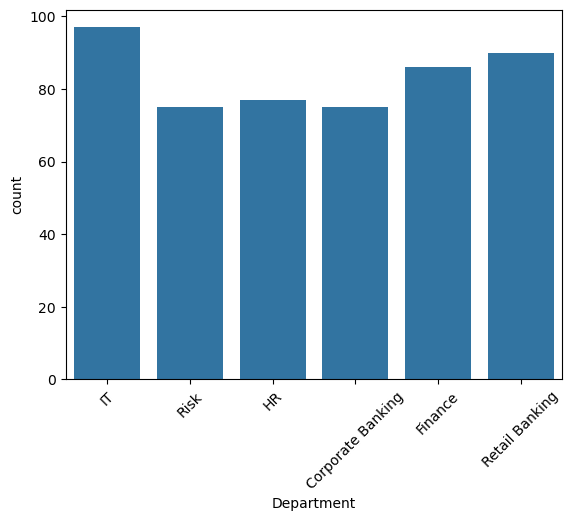

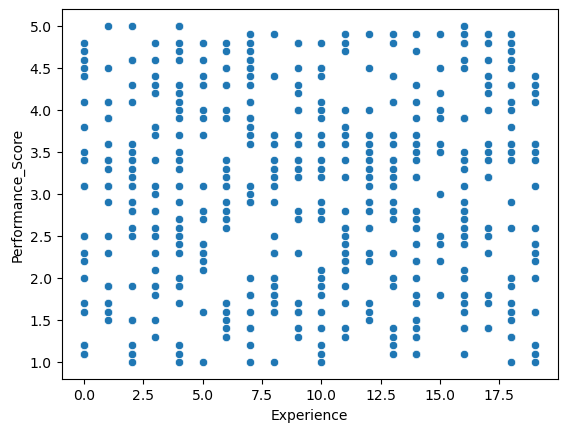

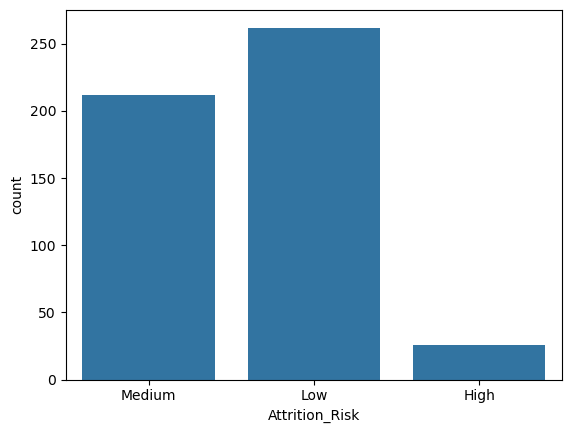

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Department distribution
sns.countplot(x="Department", data=data)
plt.xticks(rotation=45)
plt.show()

# Performance vs Experience
sns.scatterplot(x="Experience", y="Performance_Score", data=data)
plt.show()

# Attrition distribution
sns.countplot(x="Attrition_Risk", data=data)
plt.show()